![lop](../../images/logo_diive1_128px.png)

<span style='font-size:40px; display:block;'>
<b>
    Problematic sonic periods 2021-2023
</b>
</br>
  
</span>

---
**Author**: Lukas Hörtnagl (holukas@ethz.ch)  

</br>

# **IMPORTS**

- This notebook uses `diive` ([source code](https://github.com/holukas/diive)) to check eddy covariance fluxes for quality

In [6]:
import importlib.metadata
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats
import seaborn as sns

from diive.core.dfun.stats import sstats  # Time series stats
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.timeseries import TimeSeries  # For simple (interactive) time series plotting
from diive.pkgs.flux.hqflux import analyze_highest_quality_flux
from diive.pkgs.fluxprocessingchain.fluxprocessingchain import FluxProcessingChain
from diive.pkgs.fluxprocessingchain.fluxprocessingchain import LoadEddyProOutputFiles

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.86.0


</br>

</br>

# **LOAD DATA** (2 options)

## Option 2: Load data from `parquet` file
- Can be used to continue a previous session where another flux variable was already post-processed
- For example, if you have already post-processed CO2 flux and now want to post-process H2O flux
- Also detects time resolution of time series, this info was lost when saving to the parquet file

If you want to load data directly from a specific parquet file, you can specify its name and location here:

In [10]:
SOURCEDIR = r"../30_MERGE_DATA"
FILENAME = r"33.3_CH-CHA_IRGA+QCL+LGR+M10+MGMT_Level-1_eddypro_fluxnet_2005-2024.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
print(f"Data will be loaded from the following file:\n{FILEPATH}")

Data will be loaded from the following file:
..\30_MERGE_DATA\33.3_CH-CHA_IRGA+QCL+LGR+M10+MGMT_Level-1_eddypro_fluxnet_2005-2024.parquet


In [11]:
maindf = load_parquet(filepath=FILEPATH)

Loaded .parquet file ..\30_MERGE_DATA\33.3_CH-CHA_IRGA+QCL+LGR+M10+MGMT_Level-1_eddypro_fluxnet_2005-2024.parquet (3.631 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


In [57]:
maindf

,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,...,ZL_UNCORR,SWC_GF1_0.15_1_gfXG_MEAN3H,TS_GF1_0.04_1_gfXG_MEAN3H,TS_GF1_0.15_1_gfXG_MEAN3H,TS_GF1_0.4_1_gfXG_MEAN3H,PREC_RAIN_TOT_GF1_0.5_1_MEAN3H
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2005-01-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 21:45:00,1008.04,1.26052,0.022931,1270.66,0.0,1.0,...,-0.060054,52.381843,3.543930,4.427296,5.526472,0.0
2024-12-31 22:15:00,1008.00,1.26101,0.022923,1271.10,0.0,1.0,...,-0.066556,52.423854,3.526228,4.431297,5.526472,0.0
2024-12-31 22:45:00,1008.00,1.26068,0.022929,1270.77,0.0,1.0,...,-0.067016,52.496681,3.502270,4.434965,5.525231,0.0


# **Accurate time periods of problematic sonic measurements** (W_UNROT offsets)

In [186]:
[print(c) for c in maindf.columns if "AOA" in c]

AOA_METHOD
VM97_AOA_HF


[None, None]

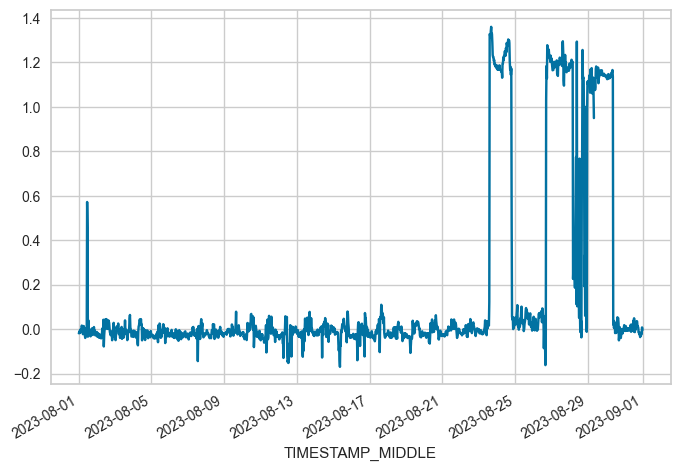

In [229]:
# maindf.loc[maindf.index.year == 2009, 'W_UNROT'].plot(x_compat=True)
# maindf.loc[maindf.index.year == 2023, 'VM97_AOA_HF'].resample('D').median().plot(x_compat=True)
maindf.loc[(maindf.index.year == 2023) & (maindf.index.month == 8), 'W_UNROT'].plot(x_compat=True);

```
Problematic time periods originally from documentation by YW:
REMOVE_DATES = [    
    1  ['2021-12-10', '2021-12-23'], # sonic problem
    2  ['2022-11-18 00:00', '2022-11-22 00:00'], # sonic w offsets
    3  ['2022-12-16 00:00', '2022-12-17 12:00'], # sonic w offsets
    4  ['2023-04-17 00:00', '2023-04-20 09:00'], # sonic w offsets
    5  ['2023-07-21 16:00', '2023-07-21 21:00'], # sonic w offsets
    6  ['2023-08-23 15:00', '2023-08-24 22:00'], # sonic w offsets
    7  ['2023-08-26 14:00', '2023-08-30 12:00'], # sonic w offsets
    8  ['2023-09-14 00:00', '2023-09-18 19:00'], # sonic w offsets
    9  ['2023-09-22 02:00', '2023-09-26 18:00'], # sonic w offsets
    10 ['2023-09-28 10:00', '2023-09-29 16:00'] # sonic w offsets
]
```

## 2021: not offset issue, use AoA flag

OFFSET betwenn 2021-12-10 00:15 and 2021-12-23 23:45: -0.0359148000680851


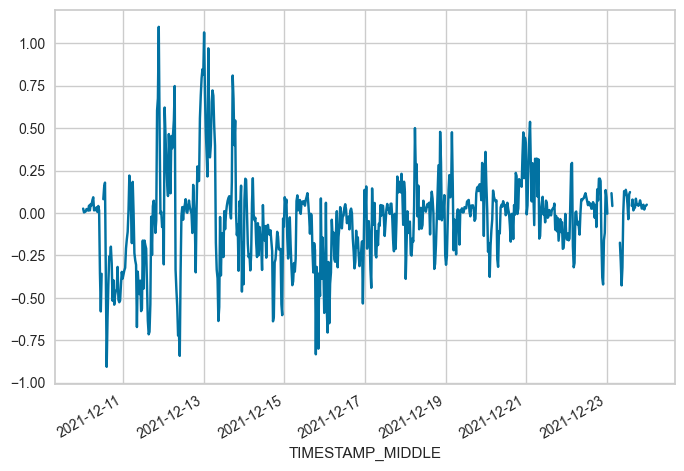

In [217]:
# Phase 1
FROM = "2021-12-10 00:15"
TO = "2021-12-23 23:45"
locs = (maindf.index >= FROM) & (maindf.index <= TO)
subset = maindf.loc[locs, 'W_UNROT'].copy()
subset.plot(x_compat=True)
print(f"OFFSET betwenn {FROM} and {TO}: {subset.mean()}")

## 2022: short periods, use with other data

OFFSET betwenn 2022-11-18 04:15 and 2022-11-20 23:45: -1.212554544117647


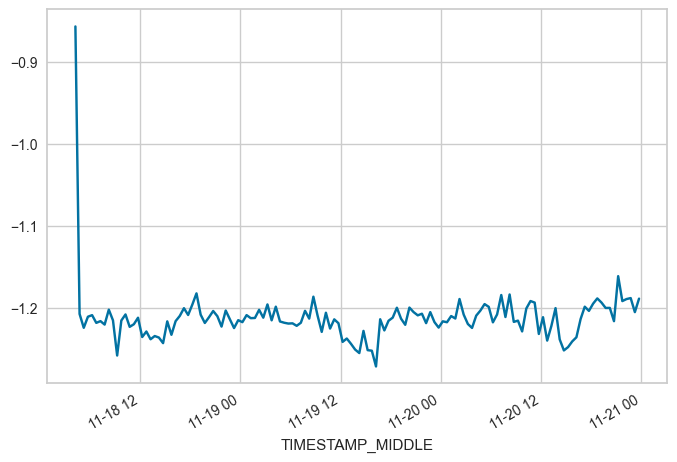

In [181]:
# Phase 2
FROM = "2022-11-18 04:15"
TO = "2022-11-20 23:45"
locs = (maindf.index >= FROM) & (maindf.index <= TO)
subset = maindf.loc[locs, 'W_UNROT'].copy()
subset.plot(x_compat=True)
print(f"OFFSET betwenn {FROM} and {TO}: {subset.mean()}")

OFFSET betwenn 2022-12-16 15:45 and 2022-12-17 07:45: -1.1005000000000003


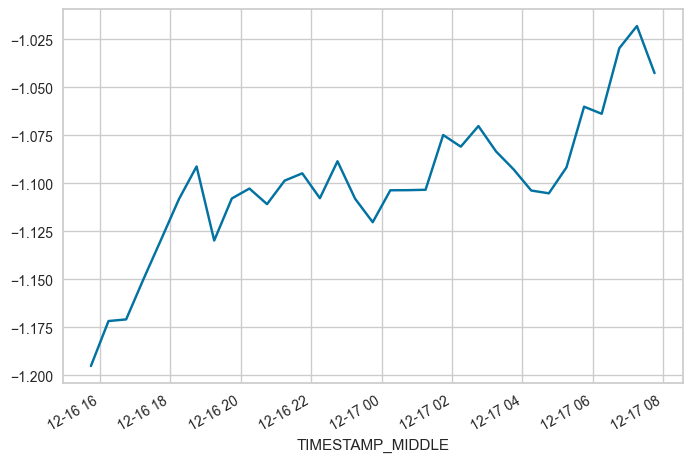

In [160]:
# Phase 3
FROM = "2022-12-16 15:45"
TO = "2022-12-17 07:45"
locs = (maindf.index >= FROM) & (maindf.index <= TO)
subset = maindf.loc[locs, 'W_UNROT'].copy()
subset.plot(x_compat=True)
print(f"OFFSET betwenn {FROM} and {TO}: {subset.mean()}")

## 2023: recalculate fluxes using wind speed measurement offset for `W` in EddyPro

OFFSET between 2023-04-17 10:15 and 2023-04-20 06:15: 1.163599708029197


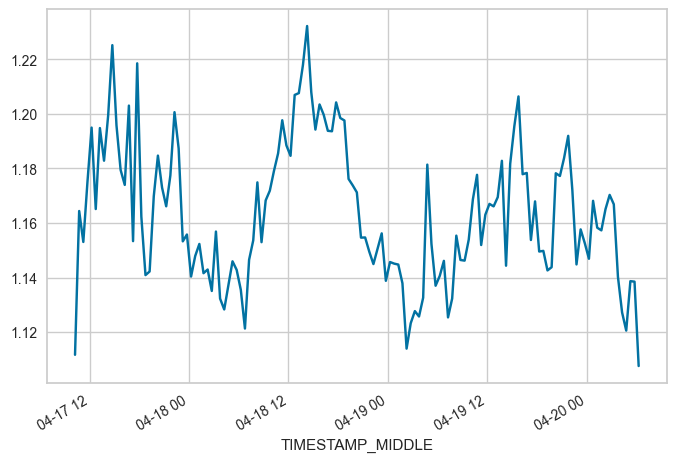

In [197]:
# Phase 4
FROM = "2023-04-17 10:15"
TO = "2023-04-20 06:15"
locs = (maindf.index >= FROM) & (maindf.index <= TO)
subset = maindf.loc[locs, 'W_UNROT'].copy()
subset.plot(x_compat=True)
print(f"OFFSET between {FROM} and {TO}: {subset.mean()}")

OFFSET between 2023-07-21 15:45 and 2023-07-21 18:45: 1.1862112857142857


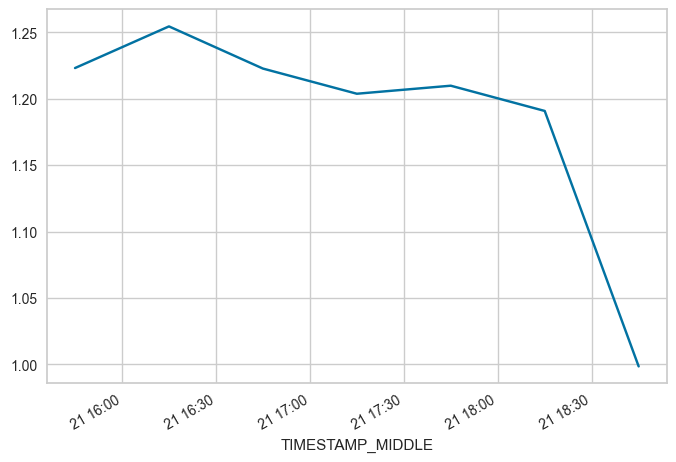

In [198]:
# Phase 5
FROM = "2023-07-21 15:45"
TO = "2023-07-21 18:45"
locs = (maindf.index >= FROM) & (maindf.index <= TO)
subset = maindf.loc[locs, 'W_UNROT'].copy()
subset.plot(x_compat=True)
print(f"OFFSET between {FROM} and {TO}: {subset.mean()}")

OFFSET between 2023-08-23 14:15 and 2023-08-24 18:45: 1.2251075862068965


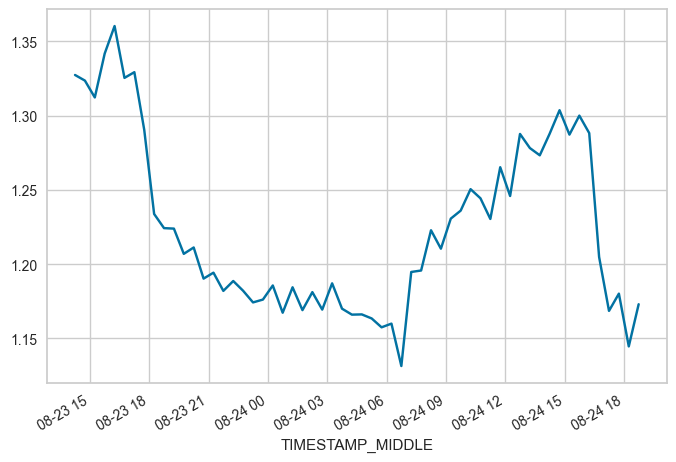

In [199]:
# Phase 6
FROM = "2023-08-23 14:15"
TO = "2023-08-24 18:45"
locs = (maindf.index >= FROM) & (maindf.index <= TO)
subset = maindf.loc[locs, 'W_UNROT'].copy()
subset.plot(x_compat=True)
print(f"OFFSET between {FROM} and {TO}: {subset.mean()}")

OFFSET between 2023-08-26 16:45 and 2023-08-30 08:45: 1.0117830873920455


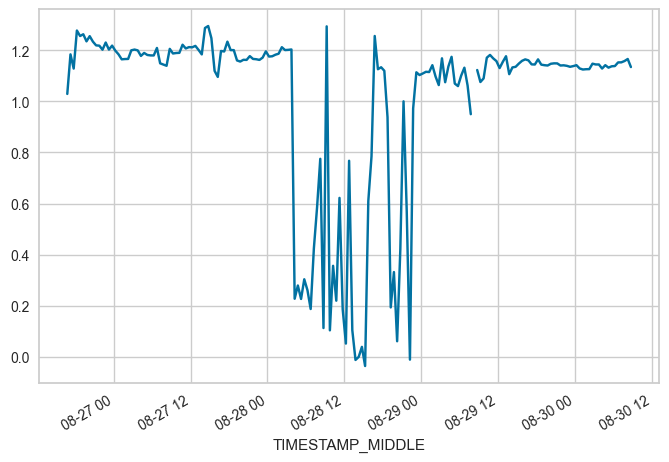

In [200]:
# Phase 7
FROM = "2023-08-26 16:45"
TO = "2023-08-30 08:45"
locs = (maindf.index >= FROM) & (maindf.index <= TO)
subset = maindf.loc[locs, 'W_UNROT'].copy()
subset.plot(x_compat=True)
print(f"OFFSET between {FROM} and {TO}: {subset.mean()}")

OFFSET between 2023-09-14 00:45 and 2023-09-18 15:45: 1.187201864864865


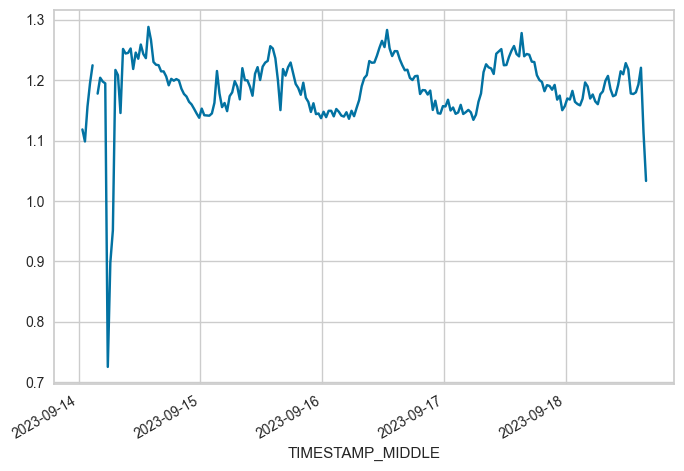

In [201]:
# Phase 8
FROM = "2023-09-14 00:45"
TO = "2023-09-18 15:45"
locs = (maindf.index >= FROM) & (maindf.index <= TO)
subset = maindf.loc[locs, 'W_UNROT'].copy()
subset.plot(x_compat=True)
print(f"OFFSET between {FROM} and {TO}: {subset.mean()}")

OFFSET between 2023-09-22 00:45 and 2023-09-26 14:45: 1.1451817454545454


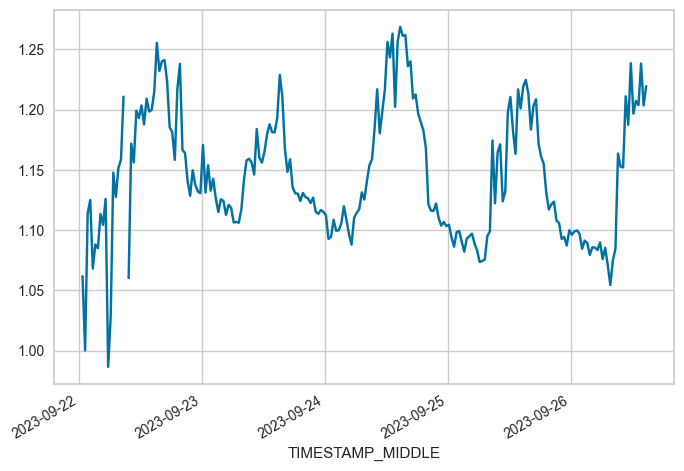

In [202]:
# Phase 9
FROM = "2023-09-22 00:45"
TO = "2023-09-26 14:45"
locs = (maindf.index >= FROM) & (maindf.index <= TO)
subset = maindf.loc[locs, 'W_UNROT'].copy()
subset.plot(x_compat=True)
print(f"OFFSET between {FROM} and {TO}: {subset.mean()}")

OFFSET between 2023-09-28 08:45 and 2023-09-29 14:15: 1.132388540677966


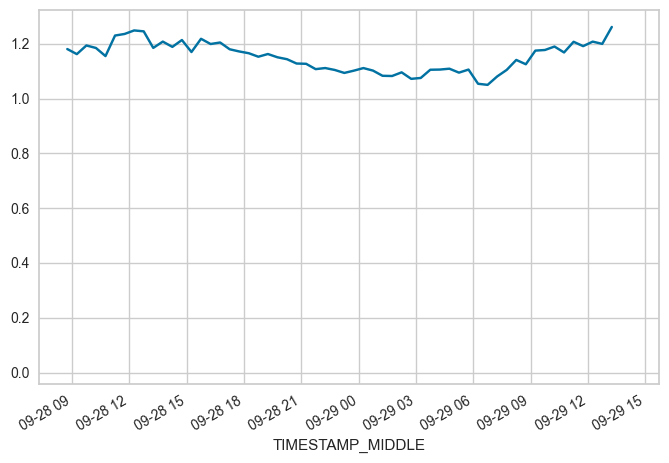

In [203]:
# Phase 10
FROM = "2023-09-28 08:45"
TO = "2023-09-29 14:15"
locs = (maindf.index >= FROM) & (maindf.index <= TO)
subset = maindf.loc[locs, 'W_UNROT'].copy()
subset.plot(x_compat=True)
print(f"OFFSET between {FROM} and {TO}: {subset.mean()}")

</br>

# **End of notebook**

Congratulations, you reached the end of this notebook! Before you go let's store your finish time.

In [73]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-03-01 18:58:19
